In [1]:
import pandas as pd

import scarf

scarf.configure_output(level='WARNING', progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='bastidas-ponce_4K_pancreas-d15_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)

ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
    default_assay='RNA',
)

pseudotime = ds.run_pseudotime_scoring(
    source_sink_key='clusters',
    sources=['Ductal'],
    sinks=['Alpha', 'Beta', 'Delta'],
)
pseudotime_key = pseudotime.pseudotime_key
validity_key = pseudotime.validity_key

Downloading bucket files: 37077563 / 37077563 complete

Downloading bytes: 37077563 / 37077563 complete

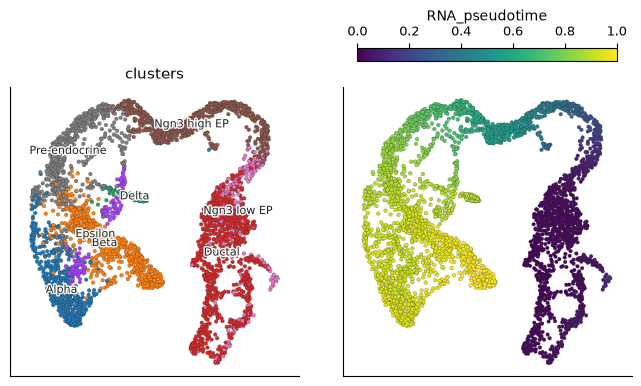

In [2]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=['clusters', pseudotime_key],
    n_columns=2,
    legend_loc='on_data',
)

In [3]:
modules = ds.run_pseudotime_aggregation(
    cell_key=validity_key,
    pseudotime_key=pseudotime_key,
    cluster_label='pseudotime_clusters',
    n_clusters=15,
    window_size=200,
    chunk_size=100,
)

Binning over cell-ordering: 1 / 1 complete

Fitting feature KNN: 1 / 1 complete

Identifying feature neighbors: 1 / 1 complete

Sorting clusters: 1 / 1 complete

In [4]:
ptime_feat = ds.RNA.feats.to_pandas_dataframe(
    columns=['names', modules.cluster_key]
)
ptime_feat[modules.cluster_key].value_counts().sort_index()

pseudotime_clusters
-1     15561
 1       959
 2      1017
 3       607
 4       961
 5       365
 6       864
 7       674
 8      1008
 9      1207
 10      448
 11      804
 12      984
 13     1179
 14      901
 15      459
Name: count, dtype: int64

In [5]:
assigned = ptime_feat[ptime_feat[modules.cluster_key] != -1]
representatives = (
    assigned.groupby(modules.cluster_key, sort=True)['names']
    .first()
    .rename('representative gene')
)
representatives

pseudotime_clusters
1      Lactb2
2     Ppp1r42
3        Mcm3
4        Rpl7
5      Mrpl15
6       Snhg6
7      Adgrb3
8       Cops5
9     Ccdc115
10       Phf3
11      Stau2
12     Sdhaf4
13      Tcf24
14      Ncoa2
15     Vcpip1
Name: representative gene, dtype: object

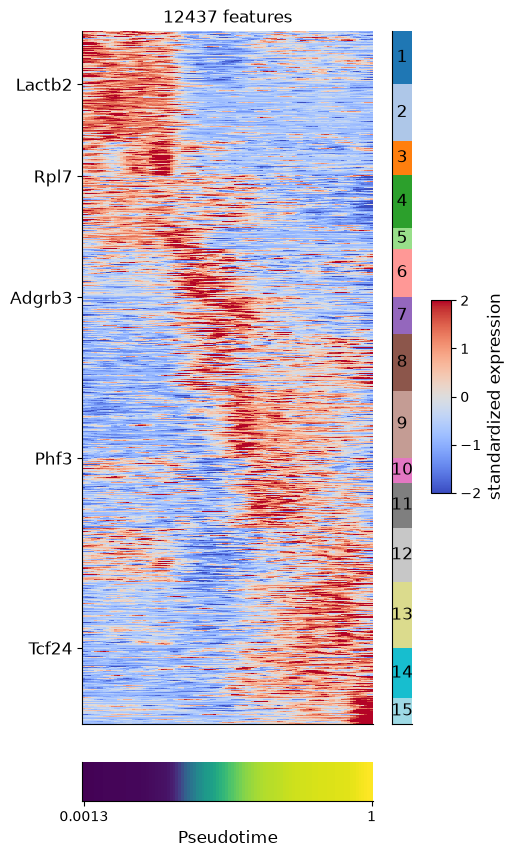

In [6]:
genes_to_label = representatives.iloc[::3].tolist()

ds.plots.pseudotime_heatmap(
    cell_key=modules.cell_key,
    feat_key=modules.feature_key,
    feature_cluster_key=modules.cluster_key,
    pseudotime_key=modules.pseudotime_key,
    show_features=genes_to_label,
)

In [7]:
ds.add_grouped_assay(
    group_key=modules.cluster_key,
    assay_label='PTIME_MODULES'
)

Computing grouped means: 15 / 15 complete

Writing grouped assay: 1 / 1 complete

Computing PTIME_MODULES initialization statistics: 1 / 1 complete

In [8]:
module_features = ds.PTIME_MODULES.feats.fetch_all('names').tolist()
{
    "module count": len(module_features),
    "cells": int(ds.PTIME_MODULES.rawData.shape[0]),
    "first modules": module_features[:5],
}

{'module count': 15,
 'cells': 3696,
 'first modules': ['group_1', 'group_2', 'group_3', 'group_4', 'group_5']}

In [9]:
pd.DataFrame(
    ds.PTIME_MODULES.rawData[:5, :5].compute(),
    columns=module_features[:5],
)

,group_1,group_2,group_3,group_4,group_5
0,0.056621,0.027192,0.033587,0.207738,0.054197
1,0.086122,0.080932,0.053354,0.344711,0.090666
2,0.055596,0.030682,0.034001,0.243399,0.045774
3,0.103627,0.074669,0.094962,0.342024,0.076012
4,0.029876,0.029150,0.042284,0.273293,0.061598


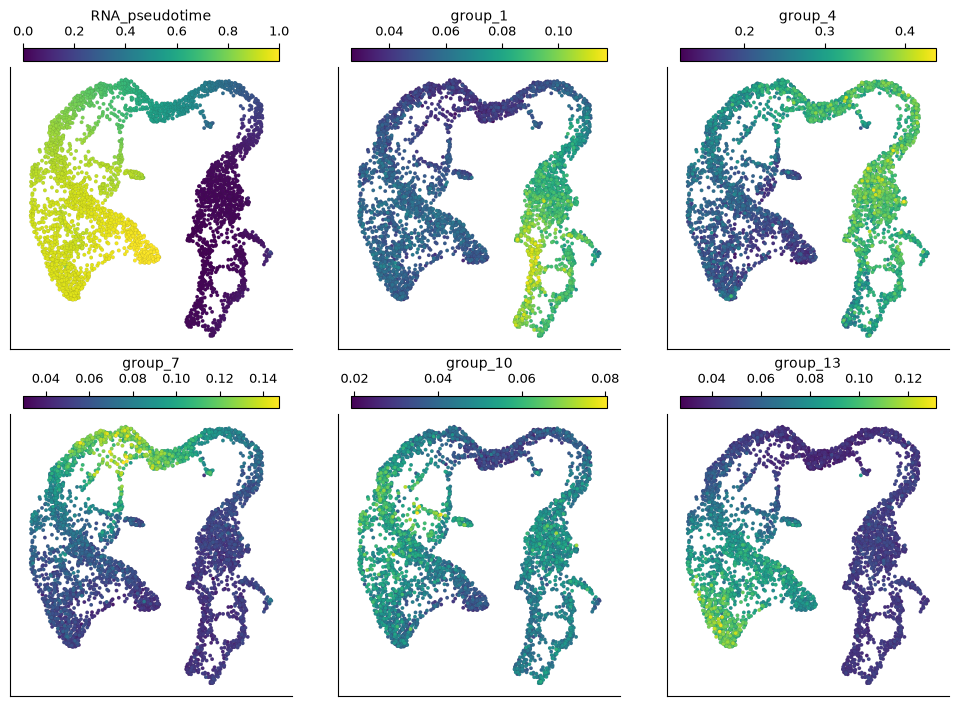

In [10]:
selected_modules = [
    f"group_{module_id}" for module_id in representatives.iloc[::3].index
]
ds.plots.embedding(
    from_assay='PTIME_MODULES',
    layout_key='RNA_UMAP',
    color_by=[pseudotime_key, *selected_modules],
    n_columns=3,
    sort_values=True,
)